In [1]:
from pathlib import Path
import pyreadr
import polars as pl, pandas as pd, numpy as np
from scipy.stats import gaussian_kde, mannwhitneyu, linregress
import re
from collections import defaultdict
from itertools import chain
from copy import deepcopy

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "cmr10"
plt.rcParams['axes.formatter.use_mathtext'] = True

<b>14 June 2026</b>

Applying <i>omltd</i> and <i>omlta</i> on 126 metastatic cases from TRACERx 421 <i>NCOMMS-25-48701A-Z</i>

<b>Reading-in data</b>

Read the pared down dataset from the `.rds` file to retrieve the following. First, we get the clinical characteristics of the 126 cases datasets; in a subsequent analysis, we discriminate among different subtypes of non-small cell lung cancer (NSCLC). Second, for each case, we obtain the mean cluster cancer cell fractions (equivalently, the mutational frequencies of each cluster in each of the samples); we are using the mutational clusters identified by Al Bakir et al. 2024 [Nature](https://www.nature.com/articles/s41586-023-05729-x). We provide these frequencies to [$PairTree$](https://doi.org/10.1158/2643-3230.BCD-21-0092) and [$CITUP$](https://doi.org/10.1093/bioinformatics/btv003).

In [2]:
TX_DATASET_421_CLINICAL  = Path("./data/20221109_TRACERx421_all_patient_df.rds")
TX_DATASET_421_MUTATIONS = Path("./data/mutTableAll.cloneInfo.20220726.txt")

In [3]:
data_clinical_characteristics = pyreadr.read_r(TX_DATASET_421_CLINICAL).get(None)       # `None` is a hashable dictionary key
data_clinical_characteristics["histology_multi_full"].value_counts()        # "histology_multi_full_genomically.confirmed"

histology_multi_full
LUAD             223
LUSC             131
Other             44
LUADx2             9
LUAD&LUSC          8
LUAD&Other         3
Other&Unknown      1
LUSC&Other         1
LUADx3             1
Name: count, dtype: int64

In [4]:
data_mutations = pl.read_csv(TX_DATASET_421_MUTATIONS, separator='\t')      # The "CRUK" cases are restricted to the 126/421 metastatic tumors

dict_case_mutations = {}

for case_cruk_id, case_mutations in data_mutations.group_by("tumour_id"):

    case_mutations = case_mutations.filter(
        pl.col("PyCloneCluster_SC") != "NA"
    ).with_columns(
        pl.col("PyCloneCluster_SC").cast(pl.Int16)
    )
    
    dict_case_mutations[case_cruk_id[0]] = case_mutations

metastatic_cases = list(dict_case_mutations.keys())     # cases here
is_metastatic = data_clinical_characteristics["tumour_id_muttable_cruk"].isin(metastatic_cases)

In [5]:
print("TX_mutations sees %d metastatic cases; in TX_clinical %d are matched" % (len(dict_case_mutations), is_metastatic.sum()))

# discrepancy comes from inconsistent labeling
missing_tumorid_crukid = set(dict_case_mutations.keys()) - set(data_clinical_characteristics["tumour_id_muttable_cruk"])

for q in missing_tumorid_crukid:
    q_regex_pattern = re.match(r"^CRUK\d+", "CRUK0084_Tumour2").group(0)
    q_match = data_clinical_characteristics.query(
        "cruk_id == @q_regex_pattern | \
        tumour_id_muttable_cruk == @q_regex_pattern | \
        tumour_id_per_patient == @q_regex_pattern"
    )

    if len(q_match) > 0:
        print("Missing entry found, but as %s instead of %s" % (q_regex_pattern, q))

TX_mutations sees 126 metastatic cases; in TX_clinical 125 are matched
Missing entry found, but as CRUK0084 instead of CRUK0084_Tumour2


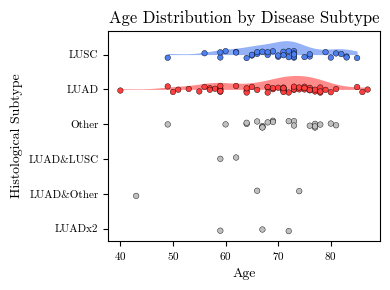

In [6]:
palette = ["#4E7FF1", "#FF3E3E"] + 4*["#C0C0C0"]

fig = plt.figure(figsize=(4, 3))
ax = sns.stripplot(
    data_clinical_characteristics[is_metastatic],
    y="histology_multi_full", hue="histology_multi_full",
    x="age", 
    size=4, 
    linewidth=0.3, 
    edgecolor='k',
    legend=False, 
    palette=palette
)

df = data_clinical_characteristics[is_metastatic]
cats = [t.get_text() for t in ax.get_yticklabels()]

def overlay_kde(ax, ages, y, color, bw=0.3, scale=0.4):
    x = np.linspace(ages.min(), ages.max(), 200)
    k = gaussian_kde(ages, bw_method=bw)(x)
    k = k / k.max() * scale
    ax.fill_between(x, y, y - k, color=color, alpha=0.6, linewidth=0)

for cat, color in zip(cats[:2], palette[:2]):
    overlay_kde(ax, df[df["histology_multi_full"] == cat]["age"].dropna(), cats.index(cat), color)

ax.set(xlabel="Age", ylabel="Histological Subtype")
ax.set_title("Age Distribution by Disease Subtype")
ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

# chronological age does not exhibit an association with histological subtype; these are likely not covariates. We observed that 
# lung adenocarcinoma demonstrates more subclonal mutations than lung squamous cell carcinoma. Demonstrate that what distinguishes
# LUAD and LUSC is not just a age stratification.

In [7]:
subtype_counts = data_clinical_characteristics[is_metastatic]["histology_multi_full"]\
    .value_counts()\
    .sort_values(ascending=False)\
    .reset_index()

subtype_counts["colors"] = ["#4E7FF1", "#FF3E3E"] + 4*["#C0C0C0"]
# subtype_counts.set_index("histology_multi_full", inplace=True)

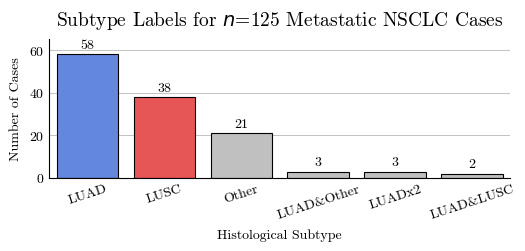

In [8]:
fig = plt.figure(figsize=(5.95, 1.8))

ax = sns.barplot(
    data = subtype_counts,
    x="histology_multi_full", hue="histology_multi_full",
    width=0.8,
    y="count",
    linewidth=0.8,
    edgecolor='k',
    palette=list(subtype_counts.colors)
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=2)

ax.tick_params(axis='x', labelsize=10, rotation=18)

ax.set_xlabel("Histological Subtype", labelpad=5, fontweight="bold")
ax.set_ylabel("Number of Cases", labelpad=5, fontweight="bold")
ax.set_title("Subtype Labels for $n$=%d Metastatic NSCLC Cases" % is_metastatic.sum(), fontsize=14, pad=10)

ax.set_ylim(0, 65)

ax.yaxis.grid(True, linewidth=0.5, color='darkgray', linestyle='-')
ax.set_axisbelow(True)
ax.tick_params(axis='both', length=0)

sns.despine()


Fetch $omlta$ results

In [9]:
def parse_mutations_tree_tsv(file):
    tree = pl.read_csv(file, separator='\t')

    return tree.select(
        pl.col("node_id"),
        pl.col("mutations").str.split(",")
    )

class AlignedTree:

    REFERENCE_MUTATION_ANNOTATIONS = dict_case_mutations
    ERR_MSG_1 = "mismatch in number of clusters"
    ERR_MSG_2 = "mismatch in number of mutations in a cluster (to other tree)"
    ERR_MSG_3 = "mismatch in number of mutations in a cluster (to label annotations)"

    def __init__(self, 
                 name: str, 
                 clustered_mutations_a: pl.DataFrame, clustered_mutations_b: pl.DataFrame, 
                 tree_alignment: pl.DataFrame
                 ):
        self.name = name
        self.node_indexed_mutations = [clustered_mutations_a, clustered_mutations_b]
        self.tree_alignment = tree_alignment

        self.labelsets = dict.fromkeys(["deleted", "matched"])
        # return 1 - \omltd
        self.compare_labelsets_identical_clusters()

    def alignment_distance(self, normalized=False) -> float:
        num_deleted, num_matched = map(
            lambda x: x["mutations"].list.len().sum(), 
            self.labelsets.values()
        )
        
        if not normalized:
            return num_deleted
        else:
            return num_deleted/(num_deleted+num_matched)
        
    def annotate_labelsets(self):
        clusters_hugo_symbols = {
            str(i): df["Hugo_Symbol"].to_list() for (i,), df in 
            AlignedTree.REFERENCE_MUTATION_ANNOTATIONS[self.name].group_by("PyCloneCluster_SC")
        }

        labelsets = {}
        for k, clustered_mutations in self.labelsets.items():
            labelsets[k] = {}
            for cluster, mutations in clustered_mutations.iter_rows():
                if (hugo_symbols := clusters_hugo_symbols.get(cluster)) is None:
                    continue
                if len(mutations) != len(hugo_symbols):
                    raise ValueError(AlignedTree.ERR_MSG_3)
                labelsets[k][cluster] = hugo_symbols

        return labelsets

    def compare_labelsets_identical_clusters(self) -> None:
        clusters_a, clusters_b = self.node_indexed_mutations
        a, b = map(lambda x: x["node_id"].sort(), [clusters_a, clusters_b])
        
        if not a.equals(b):
            raise ValueError(AlignedTree.ERR_MSG_1)     # only for ensuring all clusters in CONIPHER tree are 
                                                        # also present in the corresponding PairTree tree

        clusters_merged = clusters_a.join(clusters_b, on="node_id")\
                                    .drop_nulls()       # `NA` comparison evaluates to false
        clusters_cardinality = clusters_merged.with_columns(
            pl.col("mutations", "mutations_right").list.len()
        )

        if not clusters_cardinality["mutations"].equals(clusters_cardinality["mutations_right"]):
            raise ValueError(AlignedTree.ERR_MSG_2 + ": %s" % self.name)        # because of this, we don't have to compare
                                                                                # over the individual labels of each cluster

        # TODO: removing the first if statement would require this to evaluate the difference to both clusterings
        clusters_matched = clusters_a["node_id"].is_in(self.tree_alignment["node_id"].implode())

        self.labelsets.update(
            {
                "deleted": clusters_a.filter(~clusters_matched),
                "matched": clusters_a.filter(clusters_matched),
            }
        )


In [10]:
PARENT_WORKSPACE_DIR = Path("./vm/tree-alignment/")

In [11]:
data = {}

for f in PARENT_WORKSPACE_DIR.iterdir():
    name_case = f.stem

    # print(name_case)
    if name_case in ["CRUK0718","CRUK0497","CRUK0478"]: continue
    # TODO will be resolved; 5 Jun 2026

    tree_conipher, tree_pairtree = map(
        parse_mutations_tree_tsv,
        [
            f/f"conipher/{name_case}.conipher.txt", f/f"pairtree/{name_case}.pairtree-soln_0.txt"
        ]
    )

    (file_tree_alignment,) = f.glob("*aligned.formatted.tsv")       # compare to highest posterior probability tree sampled by PairTree

    tree_alignment = pl.read_csv(file_tree_alignment, separator='\t')
    tree_alignment = tree_alignment.with_columns(
        pl.col("node_id").cast(pl.String)
    )

    z = AlignedTree(name_case, tree_conipher, tree_pairtree, tree_alignment)

    name_case_prefix = re.match(r"CRUK\d+", name_case)\
                         .group(0)     

    data[z.name] = {
        "label_histological_subtype" : 
            data_clinical_characteristics.loc[
                data_clinical_characteristics.cruk_id == name_case_prefix, "histology_multi_full"
            ].squeeze() \
            or None,        # WARN this will silently permit cases where the histological subtype label is not present
        "labelsets_gene_annotated"  : z.annotate_labelsets(),
        "distance_tree_alignment"   : z.alignment_distance(normalized=True)
    }

The following is based on the <i>omlta</i> between the <i>CONIPHER</i> tree and the tree inferred by <i>PairTree</i> with the highest posterior probability.

Optionally, we also provide results based on aligning of the pair of inferred trees, by <i>CONIPHER</i> and <i>PairTree</i>, with the smallest <i>omltd</i>. These can be obtained by changing the path of `PARENT_WORKSPACE_DIR` to `126_tx_dataset-analysis-22may2026/tree-alignment` These demonstrate that, even when we compare the pair that are the most topologically similar, there can be substantial differences in the topological ordering of mutation labels (mutational clusters).

In [12]:
df = pd.DataFrame.from_dict(data, orient="index")
df_subtypes = df[df.label_histological_subtype.isin(["LUAD", "LUSC"])]

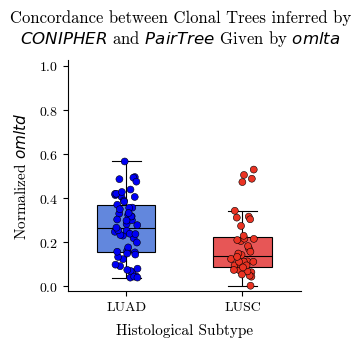

In [13]:
fig = plt.figure(figsize=(3, 3))

ax1 = sns.stripplot(
    df_subtypes,
    x="label_histological_subtype", hue="label_histological_subtype",
    y="distance_tree_alignment",
    edgecolor='k',
    linewidth=0.4,
    size=5,
    palette=["#0000F5", "#EA3323"]
)

ax2 = sns.boxplot(
    df_subtypes,
    x="label_histological_subtype", hue="label_histological_subtype",
    y="distance_tree_alignment",
    showfliers=False,
    width=0.5,
    palette=["#4E7FF1", "#FF3E3E"],
    linecolor='k',
    linewidth=0.8
)

ax2.set_xlabel("Histological Subtype", fontsize=11, labelpad=7)
ax2.set_ylabel("Normalized $omltd$", fontsize=11, labelpad=7)
ax2.set_ylim(-0.025, 1.025)

fig.suptitle("Concordance between Clonal Trees inferred by\n$CONIPHER$ and $PairTree$ Given by $omlta$", y=1.05)

sns.despine()


In [14]:
df["label_histological_subtype"] = df.label_histological_subtype.apply(
    lambda x:
    "Other Subtypes" if x not in ["LUAD", "LUSC"] else x     # Subtypes other than "luxx" are grouped togther as "other"
)

lineplot_data = pd.concat(
    [
        df.label_histological_subtype,
        (1 - df["distance_tree_alignment"])
    ],
    axis=1
)

lineplot_data = lineplot_data.sort_values("distance_tree_alignment")

full_histological_subtypes = set(lineplot_data["label_histological_subtype"].unique())
non_luxx_histological_subtypes = full_histological_subtypes.difference({"LUAD", "LUSC"})

palette = {"LUAD": "#4E7FF1", "LUSC": "#FF3E3E"}
palette.update({s: "#C0C0C0" for s in non_luxx_histological_subtypes})

counts = lineplot_data.value_counts("label_histological_subtype")\
                      .sort_values(ascending=False)

Text(0.5, 1.025, 'Tree Concordance between $CONIPHER$ and $PairTree$')

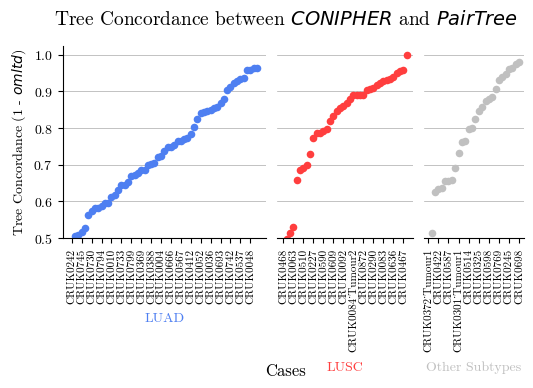

In [15]:
NUM_LABELS_TRUNCATED = 3

fig, axes = plt.subplots(
    1, len(full_histological_subtypes),
    figsize=(5.95, 2.5),
    gridspec_kw={"width_ratios": counts.values, "wspace": 0.075},
    sharey=True
)

for i, ax in enumerate(axes):
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(i == 0)
    ax.spines["top"].set_visible(False)
    if i > 0:
        ax.tick_params(left=False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color='darkgrey', linewidth=0.5)

for i, (ax, group) in enumerate(zip(axes, counts.index)):
    lineplot_data_group = lineplot_data[lineplot_data.label_histological_subtype == group]

    ax.scatter(
        x=lineplot_data_group.index,
        y=lineplot_data_group.distance_tree_alignment,
        s=30,
        linewidth=0,
        color=palette[group]
    )

    ax.set_xlabel(group, color=palette[group], labelpad=7)

    ax.set_xticks(lineplot_data_group.index[::NUM_LABELS_TRUNCATED])
    ax.set_xticklabels(lineplot_data_group.index[::NUM_LABELS_TRUNCATED], fontsize=8, rotation=90)

ax.set_ylim(0.5, 1.025)
axes[0].set_ylabel("Tree Concordance (1 - $omltd$)")
fig.supxlabel("Cases", y=-0.45)
fig.suptitle("Tree Concordance between $CONIPHER$ and $PairTree$", y=1.025, fontsize=14)

For the plots shown in figure 3 of the manuscript, we compared the <i>CONIPHER</i> tree to the highest posterior probability solution sampled by <i>PairTree</i> (alternatively, maximum likelihood can be obtained but by default, <i>PairTree</i> ranks solutions by posterior probabilities). Tree concordance was measured using $omlta$ and two common, complimentary measures of tree distance, Ancestor-Descendant and Different-Lineage Accuracy. Note that if `PARENT_WORKSPACE_DIR` was not changed above, some plots will repeat below.

<!-- The alignment files are not provided here as for the above comparisons against the <i>PairTree</i> solution with smallest $omltd$, however they can be provided on request. -->

For both Ancestor-Descendant and Different-Lineage measures, the tree inferred by <i>CONIPHER</i> is used as the ground-truth.

In [16]:
HIGHEST_LIKELIHOOD_DISTANCES = Path("./highest-posterior-probability-pairtree-solutions/")
DISTANCE_MEASURES = ["distance_omltd", "distance_ad", "distance_dl"]

comparisons_to_highest_likelihood = df.copy()
comparisons_to_highest_likelihood.drop("distance_tree_alignment", axis="columns", inplace=True)

In [17]:
distances_omltd = pd.read_csv(
    HIGHEST_LIKELIHOOD_DISTANCES/"distances_omltd/highest_likelihood_pairtree.txt",
    sep='\t',
    header=None,
    names=["case_cruk_id", "distance_omltd"],
    index_col=0
)

dict_distances_ad_dl = {}
for file in (HIGHEST_LIKELIHOOD_DISTANCES/"distances_ad_dl").glob("*soln_0.scores"):
    case_cruk_id = re.match(r"(.+)\.pairtree", file.stem).group(1)
    
    with open(file) as handle:
        lines = handle.read().split()
    
    dict_distances_ad_dl[case_cruk_id] = dict(zip(lines[0::2], map(float, lines[1::2])))

distances_ad_dl = pd.DataFrame.from_dict(dict_distances_ad_dl, orient="index")
distances_ad_dl.rename(
    columns={
        "ANCESTOR_DESCENDANT": "distance_ad", 
        "DIFFERENT_LINEAGE": "distance_dl"
    },
    inplace=True
)

comparisons_to_highest_likelihood = pd.concat(
    [
        comparisons_to_highest_likelihood, 
        distances_omltd,
        distances_ad_dl
    ], 
    axis=1
)

comparisons_to_highest_likelihood.dropna(inplace=True)      # TODO remove or handle cases above
comparisons_to_highest_likelihood_luxx = comparisons_to_highest_likelihood.query("label_histological_subtype != 'Other Subtypes'")

In [18]:
significance_text = {}
significance_value = {}

for distance_measure in DISTANCE_MEASURES:
    mask = comparisons_to_highest_likelihood_luxx["label_histological_subtype"] == "LUAD"

    stat, p = mannwhitneyu(
        comparisons_to_highest_likelihood_luxx[mask][distance_measure],
        comparisons_to_highest_likelihood_luxx[~mask][distance_measure], 
        alternative='two-sided'
    )

    print(distance_measure + f":\t{p:.4f}")
    significance_value[distance_measure] = f"$p = {p:.2e}$"

    if p < 0.001:
        significance_text[distance_measure] = "***"
    elif p < 0.01:
        significance_text[distance_measure] = "**"
    elif p < 0.05:
        significance_text[distance_measure] = "*"
    else:
        significance_text[distance_measure] = "ns"

distance_omltd:	0.0042
distance_ad:	0.1167
distance_dl:	0.9609


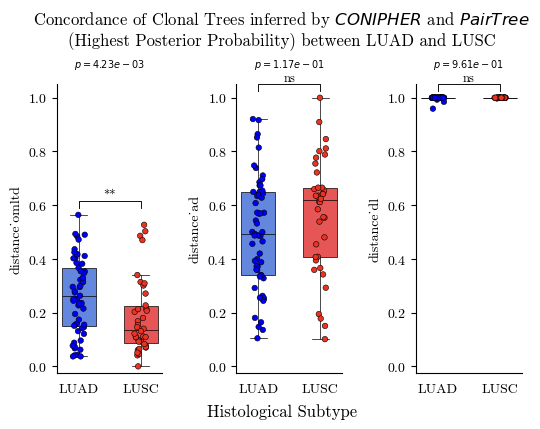

In [19]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(6, 3.75)
)

for distance_measure, ax in zip(DISTANCE_MEASURES, axes) :

    sns.stripplot(
        comparisons_to_highest_likelihood_luxx,
        x="label_histological_subtype", hue="label_histological_subtype",
        y=distance_measure,
        palette=["#0000F5", "#EA3323"],
        edgecolor='k',
        linewidth=0.4,
        size=4,
        ax=ax
    )

    sns.boxplot(
        comparisons_to_highest_likelihood_luxx,
        x="label_histological_subtype", hue="label_histological_subtype",
        y=distance_measure,
        showfliers=False,
        palette=["#4E7FF1", "#FF3E3E"],
        width=0.55,
        linecolor='k',
        linewidth=0.5,
        ax=ax
    )

    sns.despine(ax=ax)

    ax.set_ylim(-0.025, 1.05)
    ax.set_xlabel("")
    ax.tick_params(bottom=False)

    # significance annotation
    h = 0.025
    y = comparisons_to_highest_likelihood_luxx[distance_measure].max() + h
    ax.plot([0, 0, 1, 1], [y, y+h, y+h, y], linewidth=0.65, color="k")

    ax.text(
        1/2, y+h, significance_text[distance_measure], 
        ha='center', 
        va='bottom', 
        fontsize=9
    )

    ax.set_title(significance_value[distance_measure], fontsize=7, pad=12)
        
fig.supxlabel("Histological Subtype", y=-0.0125)

fig.suptitle(
    "Concordance of Clonal Trees inferred by $CONIPHER$ and $PairTree$\n" \
    "(Highest Posterior Probability) between LUAD and LUSC", 
    y=1.08
)

fig.subplots_adjust(wspace=0.7)

In [20]:
lineplot_data_highest_likelihood = pd.concat([lineplot_data, (1 - distances_omltd)], axis="columns")\
                                     .dropna()

lineplot_data_highest_likelihood.rename(
    columns={
        "distance_tree_alignment" : "distance_tree_alignment_best",
        "distance_omltd"          : "distance_tree_alignment_likelihood"
    },
    inplace=True
)

lineplot_data_highest_likelihood.sort_values("distance_tree_alignment_likelihood", inplace=True)

Text(0.5, 0.98, 'Tree Concordance between $CONIPHER$ and $PairTree$')

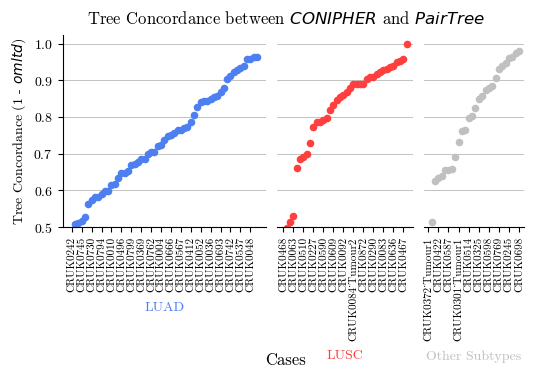

In [21]:
NUM_LABELS_TRUNCATED = 3

fig, axes = plt.subplots(
    1, len(full_histological_subtypes),
    figsize=(5.95, 2.5),
    gridspec_kw={"width_ratios": counts.values, "wspace": 0.075},
    sharey=True
)

for i, ax in enumerate(axes):
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(i == 0)
    ax.spines["top"].set_visible(False)
    if i > 0:
        ax.tick_params(left=False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color='darkgrey', linewidth=0.5)

for i, (ax, group) in enumerate(zip(axes, counts.index)):
    lineplot_data_group = lineplot_data_highest_likelihood[lineplot_data_highest_likelihood.label_histological_subtype == group]

    ax.scatter(
        x=lineplot_data_group.index,
        y=lineplot_data_group.distance_tree_alignment_likelihood,
        s=30,
        linewidth=0,
        color=palette[group]
    )

    ax.set_xlabel(group, color=palette[group], labelpad=7)

    ax.set_xticks(lineplot_data_group.index[::NUM_LABELS_TRUNCATED])
    ax.set_xticklabels(lineplot_data_group.index[::NUM_LABELS_TRUNCATED], fontsize=8, rotation=90)

ax.set_ylim(0.5, 1.025)
axes[0].set_ylabel("Tree Concordance (1 - $omltd$)")
fig.supxlabel("Cases", y=-0.45)
fig.suptitle("Tree Concordance between $CONIPHER$ and $PairTree$")

For a mutation assigned to vertex $v$ in tree $T$ with vertex set $V$, the CCF (cancer cell fraction) of that mutation is $\frac{|\{v\} \cup D(v)|}{|V|}$, where $D(v)$ is the set of descendants of $v$. The tree inferred by <i>CONIPHER</i> was used to evaluate these tree-implied CCFs.

In [22]:
CONIPHER_TREES = Path("./tree-alignment/").glob("*/conipher/*.conipher.txt")

In [23]:
def count_vertex_descendants(tree: dict[str, str]) -> dict[str, int]:

    k, v = zip(*tree.items())

    leaves = set(k) - set(v) 

    vertex_has_parent = tree.keys()
    vertex_num_descendants, already_visited_parents = defaultdict(int), {vx: 0 for vx in k}

    for l in leaves:
        counter = 1

        while l in vertex_has_parent:       
            # for each leaf vertex, traverse through their parents until either 
            # the root or a previously observed common parent/ancestor is found
            vertex_num_descendants[l] = counter

            if (parent := tree[l]) in vertex_num_descendants.keys():
                already_visited_parents[parent] += counter
                break

            l = parent
            counter += 1

    for n, a in already_visited_parents.items():
        if a == 0:
            continue
        vertex_num_descendants[n] += a

        while (parent := tree[n]) in k:
            n = parent
            vertex_num_descendants[n] += a

    return dict(vertex_num_descendants)

In [24]:
mean_cancer_cell_fractions = {}

for file in CONIPHER_TREES:
    name_case = file.stem.replace(".conipher", "")

    example_tree = pd.read_csv(file, sep='\t')\
                    .dropna()
                    
    vertex_num_descendants = pd.DataFrame.from_dict(
        count_vertex_descendants(
            example_tree.set_index("node_id")["parent_id"]\
                        .to_dict()
        ), 
        orient="index", 
        columns=["num_descendants"]
    )

    mutation_clonality = pd.concat(
        [
            example_tree.set_index("node_id"),
            vertex_num_descendants
        ],
        axis="columns"
    )

    mutation_clonality["inferred_frequency"] = mutation_clonality["num_descendants"] / len(mutation_clonality)
    mutation_clonality["num_mutations"] = mutation_clonality["mutations"].apply(lambda x: len(x.split(",")))

    mean_cancer_cell_fraction = np.average(
        mutation_clonality["inferred_frequency"],
        weights=mutation_clonality["num_mutations"]
    )

    mean_cancer_cell_fractions[name_case] = mean_cancer_cell_fraction

In [25]:
subtype_mutation_clonality = pd.concat(
    [
        comparisons_to_highest_likelihood, 
        pd.DataFrame.from_dict(mean_cancer_cell_fractions, orient="index", columns=["mean_ccf"])
    ],
    axis="columns"
)

subtype_mutation_clonality.dropna(inplace=True)
luxx_mutation_clonality = subtype_mutation_clonality.query("label_histological_subtype != 'Other Subtypes'")

In [26]:
mask = luxx_mutation_clonality["label_histological_subtype"] == "LUAD"

stat, p = mannwhitneyu(
    luxx_mutation_clonality[mask]["mean_ccf"],
    luxx_mutation_clonality[~mask]["mean_ccf"], 
    alternative='two-sided'
)

print(f"mean cancer cell fraction:\t{p:.4f}")
significance_value = f"$p = {p:.2e}$"

if p < 0.001:
    significance_text = "***"
elif p < 0.01:
    significance_text = "**"
elif p < 0.05:
    significance_text = "*"
else:
    significance_text = "ns"

mean cancer cell fraction:	0.0056


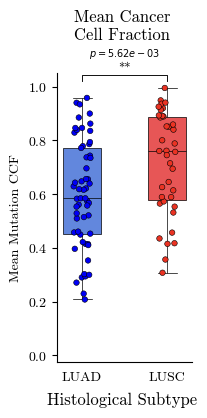

In [27]:
fig = plt.figure(figsize=(1.75, 3.75))

ax1 = sns.stripplot(
    luxx_mutation_clonality,
    x="label_histological_subtype", hue="label_histological_subtype",
    y="mean_ccf",
    palette=["#0000F5", "#EA3323"],
    edgecolor='k',
    linewidth=0.4,
    size=4
)

ax2 = sns.boxplot(
    luxx_mutation_clonality,
    x="label_histological_subtype", hue="label_histological_subtype",
    y="mean_ccf",
    showfliers=False,
    palette=["#4E7FF1", "#FF3E3E"],
    width=0.45,
    linecolor='k',
    linewidth=0.5
)

# significance annotation
h = 0.025
y = luxx_mutation_clonality["mean_ccf"].max() + h
ax2.plot([0, 0, 1, 1], [y, y+h, y+h, y], linewidth=0.65, color="k")

ax2.text(
    1/2, y+h, significance_text, 
    ha='center', 
    va='bottom', 
    fontsize=9
)

ax2.set_title(significance_value, fontsize=7, pad=12)
ax2.set_xlabel("")
ax2.set_ylabel("Mean Mutation CCF")

ax2.set_ylim(-0.025, 1.05)
ax2.tick_params(bottom=False)

fig.suptitle("Mean Cancer\nCell Fraction", y=1.05)
fig.supxlabel("Histological Subtype", y=-0.0125)

sns.despine()

In [28]:
luxx_mutation_clonality["tree_concordance"] = 1 - luxx_mutation_clonality["distance_omltd"]

In [29]:
m, y, pearsons_r, p, *_ = linregress(luxx_mutation_clonality["mean_ccf"], luxx_mutation_clonality["tree_concordance"])

In [30]:
f"$r$ = {(pearsons_r):.2f}", f"$p = {p:.2e}$"

('$r$ = 0.77', '$p = 5.40e-20$')

Text(0.5, 1.04, 'Tree Concordances and Mean Cancer Cell\nFractions Across LUAD and LUSC Subtypes')

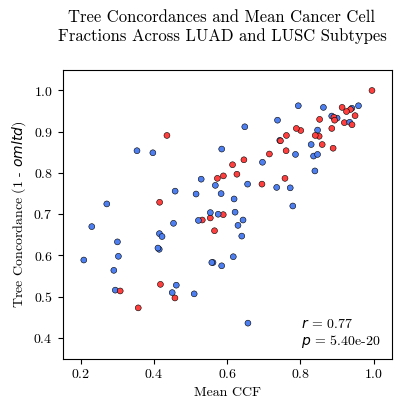

In [31]:
fig = plt.figure(figsize=(4.25, 3.75))

ax = sns.scatterplot(
    luxx_mutation_clonality,
    x="mean_ccf", y="tree_concordance",
    hue="label_histological_subtype",
    palette=["#4E7FF1", "#FF3E3E"],
    edgecolor='k',
    linewidth=0.4,
    s=18,
    legend=False
)

ax.text(
    0.725, 0.03,
    f"$r$ = {pearsons_r:.2f}\n$p$ = {p:.2e}",
    transform=ax.transAxes,
    ha='left', va='bottom',
    fontsize=10
)

ax.set_xlim(0.15, 1.05)
ax.set_ylim(0.35, 1.05)

ax.set_xlabel("Mean CCF")
ax.set_ylabel("Tree Concordance (1 - $omltd$)")

fig.suptitle("Tree Concordances and Mean Cancer Cell\nFractions Across LUAD and LUSC Subtypes", y=1.04)

Here, focusing on mutation/gene annotations for exploratory analysis based on $omlta$ label deletions. For these, we include all cases for which we have obtained tree alignments. The annotations related to the functional importance of the gene labels corresponding to the deleted mutation labels refers to the COSMIC and MSK cancer gene censuses.

In [32]:
ANNOTATION_DATA_GENE_ROLES = Path("./resources/annotations")

CSMCDB_GENE_CENSUS_FILE, MSKCDB_GENE_CENSUS_FILE = map(
    lambda f: ANNOTATION_DATA_GENE_ROLES/f, 
    ["Cosmic_CancerGeneCensus_v102_GRCh38.tsv", 
     "cancerGeneList.tsv"]
)

CSMCDB_GENE_ROLES = pd.read_csv(CSMCDB_GENE_CENSUS_FILE, sep='\t')\
                      .set_index("GENE_SYMBOL")["ROLE_IN_CANCER"]\
                      .to_dict()

MSKCDB_GENE_ROLES = pd.read_csv(MSKCDB_GENE_CENSUS_FILE, sep='\t')\
                      .set_index("Hugo Symbol")["Gene Type"]\
                      .to_dict()

# standardizing annotations between `CSMCDB` and `MSKCDB`
relabel_mskcdb_annotations = {"ONCOGENE": "oncogene", "ONCOGENE_AND_TSG": "oncogene, TSG"}
MSKCDB_GENE_ROLES = {k: relabel_mskcdb_annotations.get(v, v) for k,v in MSKCDB_GENE_ROLES.items()}

In [33]:
UNSUPPORTED_LABELS = {np.nan, "INSUFFICIENT_EVIDENCE", "NEITHER"}

MSKCDB_GENE_ROLES_deepcopy = {
    k: v for k, v in deepcopy(MSKCDB_GENE_ROLES).items()
    if not pd.isna(v)
}

MERGED_GENE_ROLES = {}

for k, v in CSMCDB_GENE_ROLES.items():

    mskcdb_annotation = MSKCDB_GENE_ROLES.get(k, np.nan)

    if v == mskcdb_annotation:
        continue        # ok; same annotation

    multiple_annotations = np.array([v, mskcdb_annotation], dtype=object)

    if len(i := np.where(~pd.isna(multiple_annotations))[0]) == 1:
        v = multiple_annotations[i][0]     # only one valid annotation
    elif len(i) == 0:
        v = "NO_ANNOTATION_AVAILABLE"
        # continue
    else:
        # multiple annotations
        v = ', '.join(
            set(multiple_annotations) - UNSUPPORTED_LABELS
        )

    MSKCDB_GENE_ROLES_deepcopy.pop(k, None)

    MERGED_GENE_ROLES[k] = v

MERGED_GENE_ROLES |= MSKCDB_GENE_ROLES_deepcopy

In [34]:
print("%d mutations/gene labels have annotations in `CMSCDB` and `MSKCDB`" % len(MERGED_GENE_ROLES))

1229 mutations/gene labels have annotations in `CMSCDB` and `MSKCDB`


In [35]:
deleted_vertex_labels_all_long = (
    pd.concat(
        [
            df["label_histological_subtype"],
            df["labelsets_gene_annotated"].apply(lambda x: list(chain.from_iterable(x["deleted"].values())))
        ],
        axis="columns"
    )
    .explode("labelsets_gene_annotated")
    .reset_index(names="case_cruk_id")
    .rename(columns={"labelsets_gene_annotated": "label_deletions"})
)

matched_vertex_labels_all_long = (
    pd.concat(
        [
            df["label_histological_subtype"],
            df["labelsets_gene_annotated"].apply(lambda x: list(chain.from_iterable(x["matched"].values())))
        ],
        axis="columns"
    )
    .explode("labelsets_gene_annotated")
    .reset_index(names="case_cruk_id")
    .rename(columns={"labelsets_gene_annotated": "label_matches"})
)

In [36]:
uniquely_deleted_vertex_labels = deleted_vertex_labels_all_long.drop_duplicates("label_deletions")
deleted_labels = set(uniquely_deleted_vertex_labels.label_deletions)

# if a mutation/gene is deleted in at least one sample (even if it is concordantly 
# placed in another tree), we consider that it is a deleted label
uniquely_matched_vertex_labels = matched_vertex_labels_all_long[
    ~matched_vertex_labels_all_long["label_matches"].isin(deleted_labels)
]

uniquely_matched_vertex_labels = uniquely_matched_vertex_labels.drop_duplicates("label_matches")

In [37]:
for k, v in {
    "label_deletions" : uniquely_deleted_vertex_labels,
    "label_matches"   : uniquely_matched_vertex_labels,
}.items():
    v["gene_role"] = v[k].apply(
        lambda x: MERGED_GENE_ROLES.get(x, "NOT_IN_LIST")
    )

num_features = sum(
    map(
        len, 
        [uniquely_deleted_vertex_labels, uniquely_matched_vertex_labels]
    )
)

gene_role_proportions = pd.DataFrame.from_dict(
    {
        "deletes": uniquely_deleted_vertex_labels.gene_role\
            .str.contains("oncogene|TSG")\
            .value_counts(),
        "matches": uniquely_matched_vertex_labels.gene_role\
            .str.contains("oncogene|TSG")\
            .value_counts()
    }
) / num_features

gene_role_proportions.rename(
    index={True: "Role in Cancer", False: "No Putative Role in Cancer"},
    columns={"deletes": "Discordant", "matches": "Concordant"},
    inplace=True
)

In [38]:
PIE_GROUP_COLOR = {"Role in Cancer": "#ED7D31", "No Putative Role in Cancer": "#d4d4d4"}
PIE_GROUP_HATCH = {"Concordant": None, "Discordant": "\\\\\\\\"}
PIE_GROUP_HATCH_LINECOLOR = {"Role in Cancer": "#A34F00", "No Putative Role in Cancer": "#818181"}

groups = gene_role_proportions.columns

piechart_data = np.empty((gene_role_proportions.size, 5), dtype=object)

u = 0
for i, val in gene_role_proportions.iterrows():
    for group in groups:
        piechart_data[u, :] = (
            f"{i} ({group})", 
            val[group] * 100, 
            PIE_GROUP_COLOR[i], 
            PIE_GROUP_HATCH[group], 
            PIE_GROUP_HATCH_LINECOLOR[i]
        )
        u += 1
    groups = groups[::-1]       # just to put categorical groups together in the plot

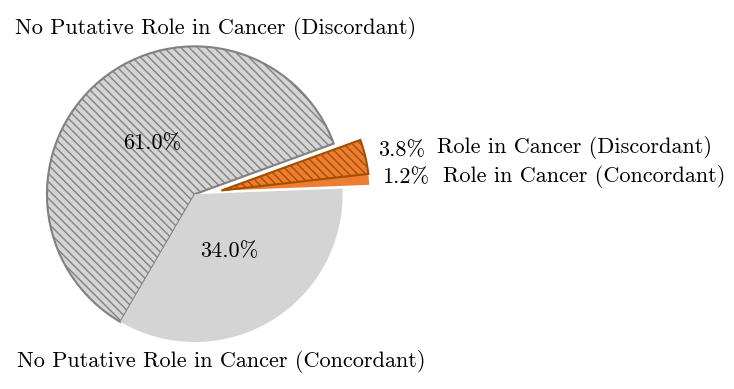

In [39]:
wedges, texts, autotexts = plt.pie(
    piechart_data[:, 1],
    labels=piechart_data[:, 0],
    colors=piechart_data[:, 2],
    autopct='%1.1f%%', 
    startangle=20,
    pctdistance=.45,
    textprops={'fontsize': 16}
)

for w_i in [2, 3]:
    wedges[w_i].set_center((.18, .025))

    angle = (wedges[w_i].theta2 + wedges[w_i].theta1) / 2
    center_x, center_y = wedges[w_i].center

    x_pct = center_x + 1.25 * np.cos(np.radians(angle))
    y_pct = center_y + 1.2 * np.sin(np.radians(angle))
    autotexts[w_i].set_position((x_pct, y_pct))

    x_label = center_x + 1.5 * np.cos(np.radians(angle))
    y_label = center_y + 1.3 * np.sin(np.radians(angle))
    texts[w_i].set_position((x_label, y_label))

for i, wedge in enumerate(wedges):
    wedge.set_hatch(piechart_data[i, 3])

    if i in [0, 3]: 
        wedge.set_edgecolor(piechart_data[i, 4])
        wedge.set_linewidth(1.5)

# adjust text
texts[0].set_position((1.5, 1.125))
texts[1].set_position((-1.2, -1.125))

Some genes can be both an "oncogene" and "tumor suppressor gene". For simplicity, we just allow these genes to be double counted.

In [40]:
mask_deleted_oncogenes, mask_matched_oncogenes = map(
    lambda lbst: (lbst["gene_role"].str.contains("oncogene")).sum(), 
    [uniquely_deleted_vertex_labels, uniquely_matched_vertex_labels]
)

mask_deleted_tsgs, mask_matched_tsgs = map(
    lambda lbst: (lbst["gene_role"].str.contains("TSG")).sum(), 
    [uniquely_deleted_vertex_labels, uniquely_matched_vertex_labels]
)

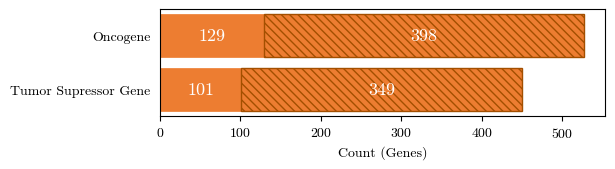

In [41]:
groups = ["Tumor Supressor Gene", "Oncogene"]
num_matched_labels = [mask_matched_tsgs, mask_matched_oncogenes]
num_deleted_labels = [mask_deleted_tsgs, mask_deleted_oncogenes]

y = np.arange(len(groups))

fig, ax = plt.subplots(figsize=(6.25, 1.8))

ax.barh(
    y, num_matched_labels, 
    color="#ED7D31",
    edgecolor="#ED7D31", 
    linewidth=0.5
)

ax.barh(
    y, num_deleted_labels, 
    left=num_matched_labels,
    color="#ED7D31", 
    edgecolor="#A34F00", 
    linewidth=1, 
    hatch="\\\\\\\\"
)

for i, x_left, x_right in zip(y, num_matched_labels, num_deleted_labels):
    ax.text(
        x_left/2, i,
        str(x_left),
        ha="center",
        va="center",
        color="white", 
        fontsize=13, 
        fontweight="bold"
    )
    ax.text(
        x_left+x_right/2, i,
        str(x_right),
        ha="center",
        va="center",
        color="white",
        fontsize=13,
        fontweight="bold"
    )

ax.tick_params(left=False)
ax.set_yticks(y)
ax.set_yticklabels(groups)
ax.set_xlabel("Count (Genes)")

plt.tight_layout()
plt.show()

Label deletions specific to LUng ADenocarcinoma and LUng Squamous Cell Carcinoma

In [42]:
subtype = "LUSC"    # replace with "LUAD" to generate corresponding scatterplot

mod = deleted_vertex_labels_all_long.query(f"label_histological_subtype == '{subtype}'")\
                                    .drop_duplicates(subset=["case_cruk_id", "label_deletions"])

we_track = set(mod["label_deletions"])

In [43]:
label_name = []
for name in mod["case_cruk_id"].unique():
    overlaps = set()

    for labels in df_subtypes.loc[name, "labelsets_gene_annotated"]["matched"].values():
        overlaps |= we_track.intersection(set(labels))

    label_name += [(name, l) for l in overlaps]

In [44]:
y = pd.concat(
    [pd.DataFrame(label_name, columns=["case_cruk_id", "label"]),
     mod[["case_cruk_id", "label_deletions"]].rename(columns={"label_deletions": "label"})],
    axis="index"
).drop_duplicates(subset=["case_cruk_id", "label"])

In [45]:
qw = y.groupby("label")["case_cruk_id"].apply(len)
qe = mod.groupby("label_deletions")["case_cruk_id"].apply(len)

In [46]:
r = pd.concat(
    [qw, qe],
    axis="columns"
)
r.columns = ["presence", "deleted"]
r["gene_role"] = [MERGED_GENE_ROLES.get(l, "NOT_IN_LIST") for l in r.index]

mask = r["gene_role"].str.contains("oncogene|TSG")
scatterplot_data = [(r[mask], "#ED7D31"), (r[~mask], "#d4d4d4")]

Text(0.5, 1.05, 'Frequency of Mutational Event and Mutational Placement Instability\nbetween $CONIPHER$ and $PairTree$ trees for LUSC tumors')

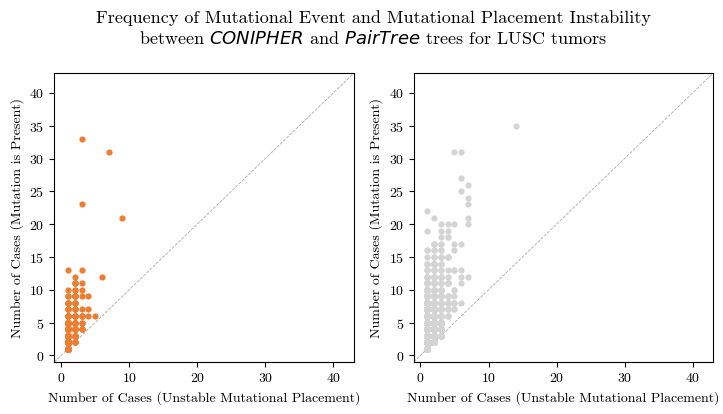

In [47]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(8.5, 3.75),
    gridspec_kw={"wspace": 0.2}
)

for i, ax in enumerate(axes):
    data, color = scatterplot_data[i]

    sns.scatterplot(
        data, 
        x="deleted", y="presence",
        s=20,
        color=color,
        linewidth=0,
        ax=ax
    )
    
    ax.set_xlim(-1, 43)
    ax.set_ylim(-1, 43)
    ax.axline((0, 0), slope=1, color="darkgrey", linewidth=0.6, linestyle="--", zorder=0)

    ax.set_xlabel("Number of Cases (Unstable Mutational Placement)")
    ax.set_ylabel("Number of Cases (Mutation is Present)")

fig.suptitle(
    "Frequency of Mutational Event and Mutational Placement Instability\n" +
    f"between $CONIPHER$ and $PairTree$ trees for {subtype} tumors",
    fontsize=13,
    y=1.05
)